In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os

path = r'C:\Users\Anirudh\Desktop\olist_project\\'
os.chdir(path)

master = pd.read_csv('olist_master.csv')

print("Master loaded ✅")
print("Shape:", master.shape)

Master loaded ✅
Shape: (110173, 38)


In [2]:
review_by_sla = master.groupby('is_late').agg(
    avg_review    = ('review_score', 'mean'),
    total_orders  = ('review_score', 'count')
).reset_index()

review_by_sla['delivery_status'] = ['On Time', 'Late']

print(review_by_sla)

   is_late  avg_review  total_orders delivery_status
0        0    4.210800        101390         On Time
1        1    2.446204          7956            Late


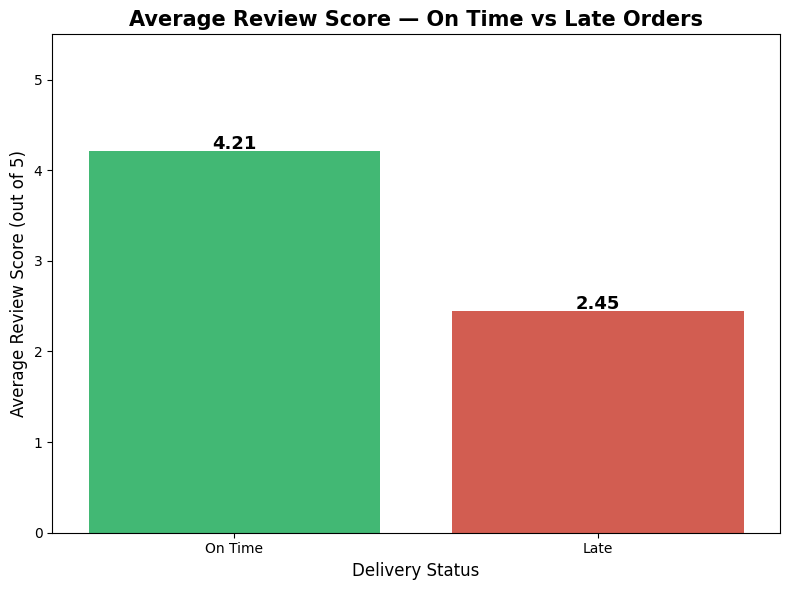

Chart 11 saved ✅


In [3]:
plt.figure(figsize=(8, 6))
bars = sns.barplot(data=review_by_sla, x='delivery_status',
                   y='avg_review',
                   palette=['#2ecc71', '#e74c3c'])

for bar, val in zip(bars.patches, review_by_sla['avg_review']):
    bars.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + 0.02,
              f'{val:.2f}', ha='center',
              fontsize=13, fontweight='bold')

plt.title('Average Review Score — On Time vs Late Orders',
          fontsize=15, fontweight='bold')
plt.xlabel('Delivery Status', fontsize=12)
plt.ylabel('Average Review Score (out of 5)', fontsize=12)
plt.ylim(0, 5.5)
plt.tight_layout()
plt.savefig('chart11_review_vs_delivery.png', dpi=150)
plt.show()
print("Chart 11 saved ✅")

In [4]:
bucket_order = ['On Time', '1-3 Days Late', '4-7 Days Late',
                '8-14 Days Late', '15+ Days Late']

# Recreate delay buckets
def delay_bucket(days):
    if days <= 0:
        return 'On Time'
    elif days <= 3:
        return '1-3 Days Late'
    elif days <= 7:
        return '4-7 Days Late'
    elif days <= 14:
        return '8-14 Days Late'
    else:
        return '15+ Days Late'

master['delay_bucket'] = master['delay_days'].apply(delay_bucket)

bucket_review = master.groupby('delay_bucket').agg(
    avg_review   = ('review_score', 'mean'),
    total_orders = ('review_score', 'count')
).reindex(bucket_order).reset_index()

print(bucket_review)

     delay_bucket  avg_review  total_orders
0         On Time    4.210800        101390
1   1-3 Days Late    3.558801          2636
2   4-7 Days Late    2.212623          1933
3  8-14 Days Late    1.720930          1806
4   15+ Days Late    1.705250          1581


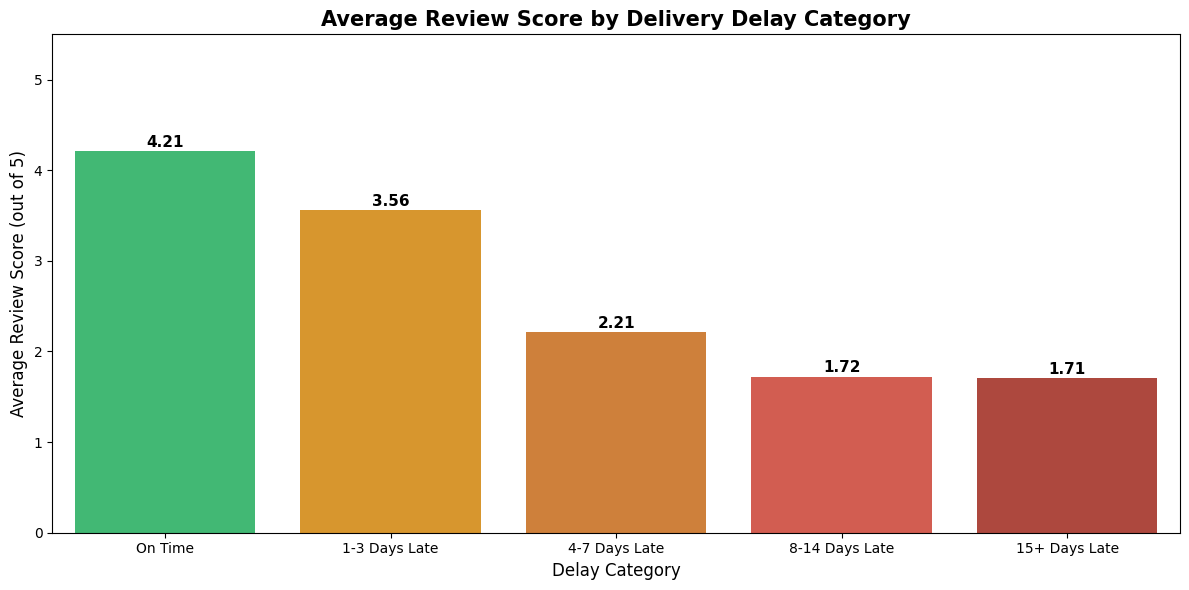

Chart 12 saved ✅


In [5]:
colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c', '#c0392b']

plt.figure(figsize=(12, 6))
bars = sns.barplot(x='delay_bucket', y='avg_review',
                   data=bucket_review, palette=colors)

for bar, val in zip(bars.patches, bucket_review['avg_review']):
    bars.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + 0.05,
              f'{val:.2f}', ha='center',
              fontsize=11, fontweight='bold')

plt.title('Average Review Score by Delivery Delay Category',
          fontsize=15, fontweight='bold')
plt.xlabel('Delay Category', fontsize=12)
plt.ylabel('Average Review Score (out of 5)', fontsize=12)
plt.ylim(0, 5.5)
plt.tight_layout()
plt.savefig('chart12_review_by_bucket.png', dpi=150)
plt.show()
print("Chart 12 saved ✅")

In [6]:
total_revenue = master['price'].sum()
late_revenue  = master[master['is_late'] == 1]['price'].sum()
ontime_revenue = master[master['is_late'] == 0]['price'].sum()

print(f"Total Revenue          : R$ {total_revenue:,.2f}")
print(f"On Time Revenue        : R$ {ontime_revenue:,.2f}")
print(f"Late Order Revenue     : R$ {late_revenue:,.2f}")
print(f"% Revenue from Late    : {round(late_revenue/total_revenue*100, 2)}%")

Total Revenue          : R$ 13,218,399.50
On Time Revenue        : R$ 12,129,673.97
Late Order Revenue     : R$ 1,088,725.53
% Revenue from Late    : 8.24%


In [7]:
state_revenue = master.groupby('customer_state').agg(
    total_revenue  = ('price', 'sum'),
    late_revenue   = ('price', lambda x: x[master.loc[x.index, 'is_late'] == 1].sum()),
    total_orders   = ('is_late', 'count'),
    late_orders    = ('is_late', 'sum')
).reset_index()

state_revenue['breach_rate'] = round(
    (state_revenue['late_orders'] / 
     state_revenue['total_orders']) * 100, 2
)

state_revenue = state_revenue.sort_values(
    'late_revenue', ascending=False)

print("=== TOP 10 STATES BY REVENUE AT RISK ===")
print(state_revenue.head(10))

=== TOP 10 STATES BY REVENUE AT RISK ===
   customer_state  total_revenue  late_revenue  total_orders  late_orders  \
25             SP     5065805.31     312959.08         46435         2430   
18             RJ     1759473.14     228594.82         14140         1756   
10             MG     1552241.03      86495.31         12913          650   
4              BA      493584.14      66265.13          3683          475   
22             RS      728205.48      49863.27          6131          392   
23             SC      507012.13      42522.29          4097          371   
7              ES      268643.45      36731.23          2225          262   
17             PR      666063.51      33235.55          5649          250   
5              CE      219677.39      31874.71          1425          211   
15             PE      251889.49      28267.77          1746          170   

    breach_rate  
25         5.23  
18        12.42  
10         5.03  
4         12.90  
22         6.39  
23 

In [8]:
orders_all = pd.read_csv('olist_orders_dataset.csv')

status_counts = orders_all['order_status'].value_counts().reset_index()
status_counts.columns = ['status', 'count']
status_counts['pct'] = round(
    status_counts['count'] / len(orders_all) * 100, 2)

print(status_counts)

        status  count    pct
0    delivered  96478  97.02
1      shipped   1107   1.11
2     canceled    625   0.63
3  unavailable    609   0.61
4     invoiced    314   0.32
5   processing    301   0.30
6      created      5   0.01
7     approved      2   0.00


In [9]:
items = pd.read_csv('olist_order_items_dataset.csv')

# Merge orders with items to get revenue
orders_items = orders_all.merge(items, on='order_id', how='left')

cancelled = orders_items[
    orders_items['order_status'] == 'canceled']

cancelled_revenue = cancelled['price'].sum()
total_revenue_all = orders_items['price'].sum()

print(f"Cancelled orders          : {orders_all[orders_all['order_status']=='canceled'].shape[0]}")
print(f"Revenue lost to cancels   : R$ {cancelled_revenue:,.2f}")
print(f"% of total revenue lost   : {round(cancelled_revenue/total_revenue_all*100,2)}%")

Cancelled orders          : 625
Revenue lost to cancels   : R$ 95,235.27
% of total revenue lost   : 0.7%


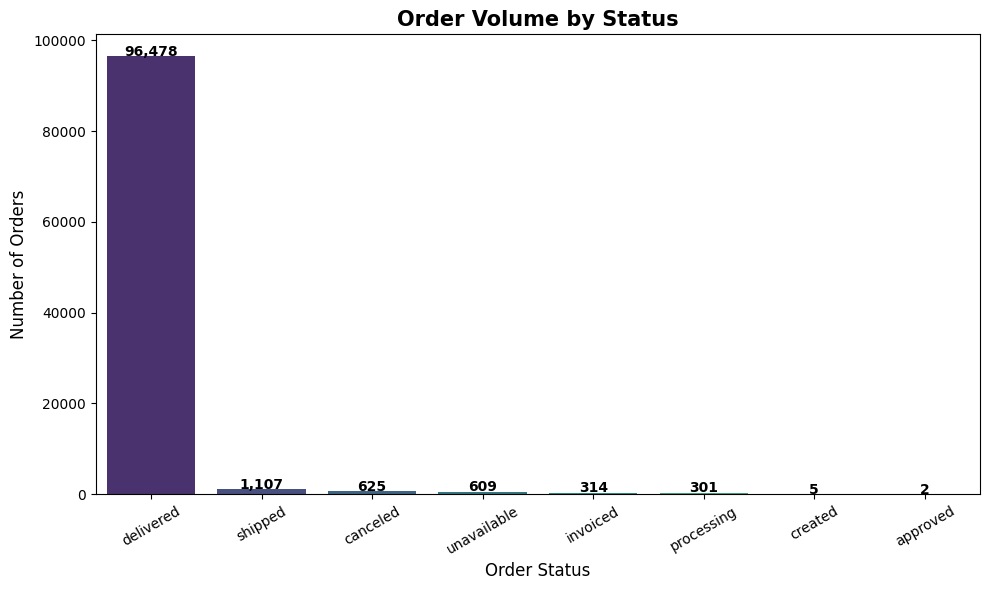

Chart 14 saved ✅


In [10]:
plt.figure(figsize=(10, 6))
bars = sns.barplot(data=status_counts, x='status',
                   y='count', palette='viridis')

for bar, val in zip(bars.patches, status_counts['count']):
    bars.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + 100,
              f'{val:,}', ha='center',
              fontsize=10, fontweight='bold')

plt.title('Order Volume by Status',
          fontsize=15, fontweight='bold')
plt.xlabel('Order Status', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('chart14_order_status.png', dpi=150)
plt.show()
print("Chart 14 saved ✅")

In [ ]:
# ===================== DAY 5 OBSERVATIONS =====================
# 1. Avg review score for ON TIME orders          = 4.21
# 2. Avg review score for LATE orders             = 2.45
# 3. Review score drop (on time - late)           = 1.76
# 4. Total revenue from late orders (R$)          = R$ 1,088,725.53
# 5. % of total revenue at risk                   = 8.24%
# 6. Revenue lost to cancellations (R$)           = R$ 95,235.27
# 7. One business insight from today              = Review score drops as delivery is delayed. This can lead to cancellation of orders and loss of reveue. 8.24% of total revenue was at risk. 
# ==============================================================